# **Auto-settings**

## Data settings

In [1]:
# DIRCONF = r'F:\Sync\luhk_work\20 - CODING\22 - POET\configs'
# # DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files: needed e.g. for connection to database
# TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)
# REQUIRED_TIME_RESOLUTION = '30min'  # 30MIN time resolution

## Imports

In [2]:
import importlib.metadata
from datetime import datetime

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from diive.core.io.files import save_parquet

sns.set_theme('notebook')
from diive.core.plotting.timeseries import TimeSeries
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import TimestampSanitizer
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.createvar.timesince import TimeSince
from diive.pkgs.gapfilling.xgboost_ts import XGBoostTS
from diive.core.io.files import load_parquet
import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.89.0


In [3]:
# Project settings (dataset period, data paths): see src/config.py
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.config import DATA_DIR, PERIOD_START, PERIOD_END, select_period

</br>

# **LOAD DATA** from files

In [4]:
filename_meteo = DATA_DIR / "METEO" / "CH-TAN_meteo_gapfilled-meteoswiss_2024-25.csv"
meteo = pd.read_csv(filename_meteo)
meteo['TIMESTAMP_MIDDLE'] = pd.to_datetime(meteo['TIMESTAMP_END'], errors='coerce').dt.tz_localize(None) - pd.Timedelta(minutes=15)
meteo = meteo.set_index('TIMESTAMP_MIDDLE')
meteo.drop(columns='TIMESTAMP_END', inplace=True)
meteo

,g,pa,ppfd,prec,rh,swc_0.05,...,prec_is_meteoswiss,sw_in_is_meteoswiss,sw_out_is_meteoswiss,lw_in_is_meteoswiss,lw_out_is_meteoswiss,ppfd_is_meteoswiss
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2024-08-22 00:15:00,-37.436829,95.590000,0.0,0.000,89.440002,16.752412,...,0,0,0,0,0,0
2024-08-22 00:45:00,-36.883657,95.579000,0.0,0.000,90.133334,16.707313,...,0,0,0,0,0,0
2024-08-22 01:15:00,-34.570664,95.556333,0.0,0.000,90.923334,16.672328,...,0,0,0,0,0,0
2024-08-22 01:45:00,-33.094323,95.527000,0.0,0.000,91.986667,16.611719,...,0,0,0,0,0,0
2024-08-22 02:15:00,-32.885476,95.500000,0.0,0.000,91.233334,16.552405,...,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,...,0,0,0,0,0,0
2025-06-04 22:15:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,...,0,0,0,0,0,0
2025-06-04 22:45:00,-21.379620,95.165333,0.0,0.425,83.819999,27.975655,...,0,0,0,0,0,0


</br>

# **Select variables**

In [5]:
# cols_subset = ['TA', 'RH', 'PA', 'SW_IN', 'LW_IN', 'PPFD_IN', 'PREC', 'SWC_0.05', 'SWC_0.15', 'SWC_0.3', 'SWC_0.5', 'TS_0.05', 'TS_0.15', 'TS_0.3', 'TS_0.5']
# meteo = meteo[cols_subset]
# meteo

# Add timesince precipitation

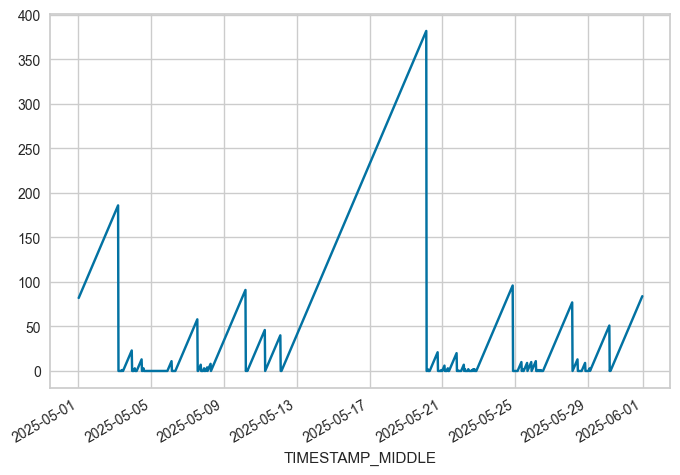

In [6]:
meteo = meteo.copy()
series_prec = meteo['prec'].copy()
ts_prec = TimeSince(series_prec, lower_lim=0, include_lim=False)
ts_prec.calc()
# ts_full_results = ts.get_full_results()
timesince = ts_prec.get_timesince()
meteo['timesince_prec'] = timesince
meteo.loc['2025-05', 'timesince_prec'].plot(x_compat=True);

# **Sanitize timestamp**

In [7]:
meteo = TimestampSanitizer(data=meteo).get()
meteo

,g,pa,ppfd,prec,rh,swc_0.05,...,sw_in_is_meteoswiss,sw_out_is_meteoswiss,lw_in_is_meteoswiss,lw_out_is_meteoswiss,ppfd_is_meteoswiss,timesince_prec
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2024-08-22 00:15:00,-37.436829,95.590000,0.0,0.000,89.440002,16.752412,...,0,0,0,0,0,1
2024-08-22 00:45:00,-36.883657,95.579000,0.0,0.000,90.133334,16.707313,...,0,0,0,0,0,2
2024-08-22 01:15:00,-34.570664,95.556333,0.0,0.000,90.923334,16.672328,...,0,0,0,0,0,3
2024-08-22 01:45:00,-33.094323,95.527000,0.0,0.000,91.986667,16.611719,...,0,0,0,0,0,4
2024-08-22 02:15:00,-32.885476,95.500000,0.0,0.000,91.233334,16.552405,...,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,...,0,0,0,0,0,0
2025-06-04 22:15:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,...,0,0,0,0,0,0
2025-06-04 22:45:00,-21.379620,95.165333,0.0,0.425,83.819999,27.975655,...,0,0,0,0,0,0


</br>

</br>

# **PLOT**

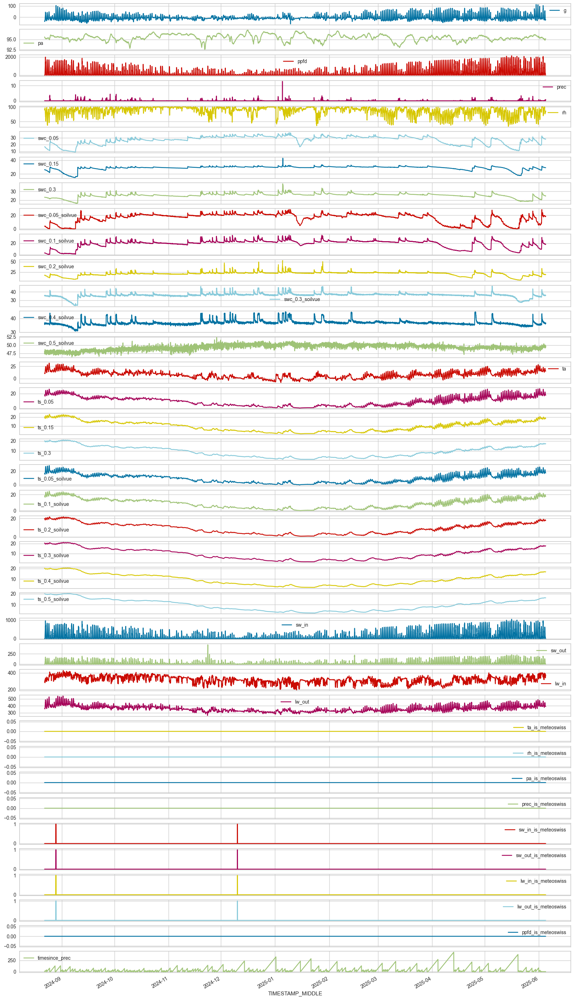

In [8]:
meteo.plot(subplots=True, x_compat=True, figsize=(20, 40));

</br>

# **Gap-filling**

Each variable is gap-filled with XGBoost only if it has missing records; otherwise the measured values are kept (`_gfXG` = measured, `FLAG_..._ISFILLED` = 0).

## SW_IN

In [9]:
var = 'sw_in'

In [10]:
_df = pd.DataFrame()
_df[var] = meteo[var].copy()
_df['sw_in_pot'] = potrad(timestamp_index=_df.index,
                          lat=47.480620,  # CH-TAN
                          lon=8.911868,  # CH-TAN
                          utc_offset=1)
_df

,sw_in,sw_in_pot
TIMESTAMP_MIDDLE,,
2024-08-22 00:15:00,0.0,0.0
2024-08-22 00:45:00,0.0,0.0
2024-08-22 01:15:00,0.0,0.0
2024-08-22 01:45:00,0.0,0.0
2024-08-22 02:15:00,0.0,0.0
...,...,...
2025-06-04 21:45:00,0.0,0.0
2025-06-04 22:15:00,0.0,0.0
2025-06-04 22:45:00,0.0,0.0


### Set nighttime data to zero

In [11]:
# Detect nighttime
from diive.pkgs.createvar.daynightflag import DaytimeNighttimeFlag
dnf = DaytimeNighttimeFlag(
    timestamp_index=_df.index,
    nighttime_threshold=0.001,
    lat=47.480620,  # CH-TAN
    lon=8.911868,  # CH-TAN
    utc_offset=1)
nighttimeflag = dnf.get_nighttime_flag()
nighttime_ix = nighttimeflag == 1

Some nighttime data is above or below zero:

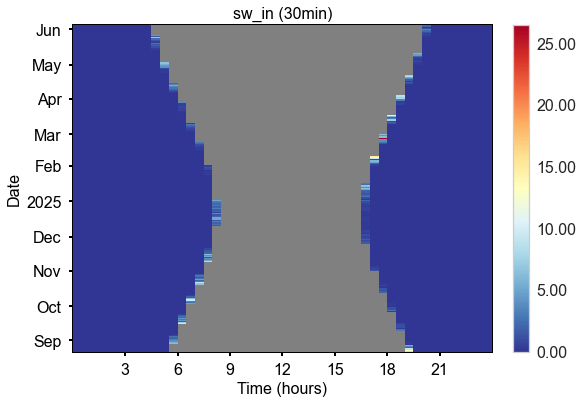

In [12]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

In [13]:
_df.loc[nighttime_ix, var].describe()

count    7405.000000
mean        0.095560
std         0.788977
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        26.485610
Name: sw_in, dtype: float64

In [14]:
_df.loc[nighttime_ix, var] = 0
_df.loc[nighttime_ix, var].describe()

count    7405.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: sw_in, dtype: float64

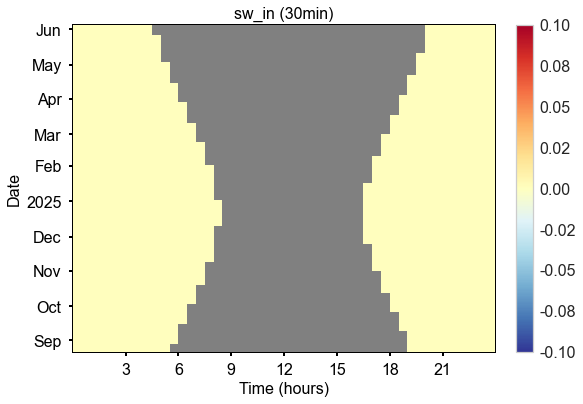

In [15]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

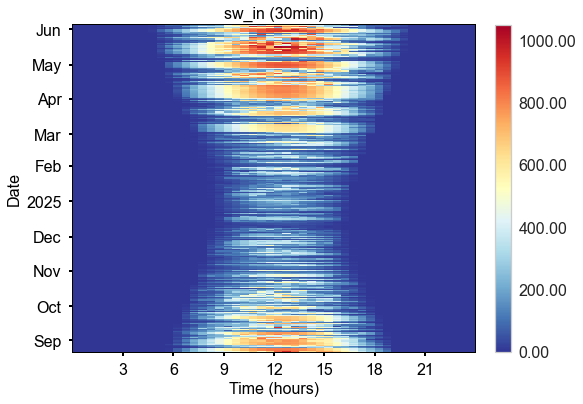

In [16]:
HeatmapDateTime(_df[var]).plot()

### Fill

In [17]:
# Gap-filling with XGBoost only if the variable has missing records
n_gaps = _df[var].isnull().sum()
if n_gaps > 0:
    print(f'{var}: {n_gaps} missing records, gap-filling with XGBoost')
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_
else:
    print(f'{var}: no missing records, gap-filling not needed')

sw_in: no missing records, gap-filling not needed


### Add to data

In [18]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [19]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

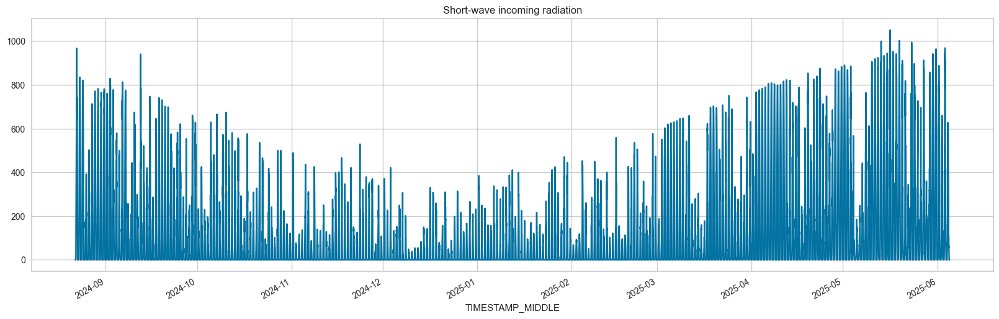

In [20]:
title = "Short-wave incoming radiation"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

</br>

## TA

In [21]:
var = 'ta'

In [22]:
_df = pd.DataFrame()
_df['sw_in'] = meteo['sw_in'].copy()
_df[var] = meteo[var].copy()
_df

,sw_in,ta
TIMESTAMP_MIDDLE,,
2024-08-22 00:15:00,0.0,11.276667
2024-08-22 00:45:00,0.0,11.043333
2024-08-22 01:15:00,0.0,10.890000
2024-08-22 01:45:00,0.0,10.720000
2024-08-22 02:15:00,0.0,10.820000
...,...,...
2025-06-04 21:45:00,0.0,15.693333
2025-06-04 22:15:00,0.0,15.516667
2025-06-04 22:45:00,0.0,15.660000


### Fill

In [23]:
# Gap-filling with XGBoost only if the variable has missing records
n_gaps = _df[var].isnull().sum()
if n_gaps > 0:
    print(f'{var}: {n_gaps} missing records, gap-filling with XGBoost')
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_
else:
    print(f'{var}: no missing records, gap-filling not needed')

ta: no missing records, gap-filling not needed


### Add to data

In [24]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [25]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

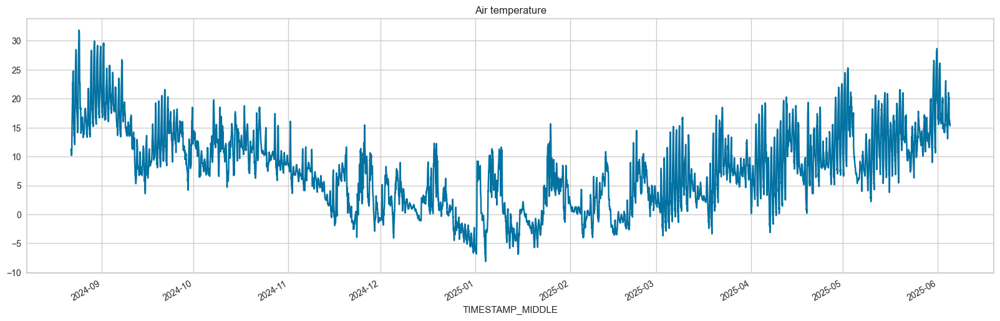

In [26]:
title = "Air temperature"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

## PPFD

In [27]:
var = 'ppfd'

In [28]:
_df = pd.DataFrame()
_df[var] = meteo[[var]].copy()
_df['sw_in'] = meteo[['sw_in']].copy()
_df

,ppfd,sw_in
TIMESTAMP_MIDDLE,,
2024-08-22 00:15:00,0.0,0.0
2024-08-22 00:45:00,0.0,0.0
2024-08-22 01:15:00,0.0,0.0
2024-08-22 01:45:00,0.0,0.0
2024-08-22 02:15:00,0.0,0.0
...,...,...
2025-06-04 21:45:00,0.0,0.0
2025-06-04 22:15:00,0.0,0.0
2025-06-04 22:45:00,0.0,0.0


### Set nighttime data to zero

In [29]:
# Detect nighttime
from diive.pkgs.createvar.daynightflag import DaytimeNighttimeFlag
dnf = DaytimeNighttimeFlag(
    timestamp_index=_df.index,
    nighttime_threshold=0.001,
    lat=47.480620,  # CH-TAN
    lon=8.911868,  # CH-TAN
    utc_offset=1)
nighttimeflag = dnf.get_nighttime_flag()
nighttime_ix = nighttimeflag == 1

Some nighttime data is above or below zero:

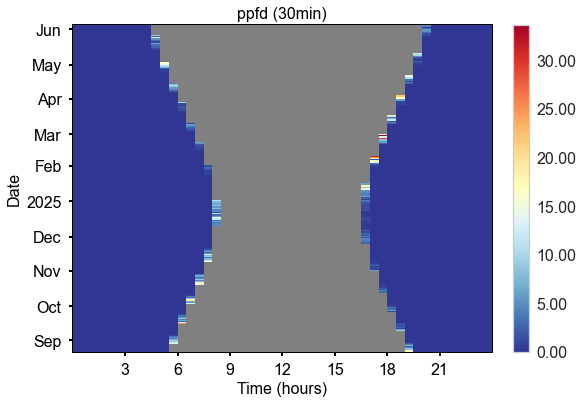

In [30]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

In [31]:
_df.loc[nighttime_ix, var].describe()

count    7405.000000
mean        0.201398
std         1.496000
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        33.681639
Name: ppfd, dtype: float64

In [32]:
_df.loc[nighttime_ix, var] = 0
_df.loc[nighttime_ix, var].describe()

count    7405.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: ppfd, dtype: float64

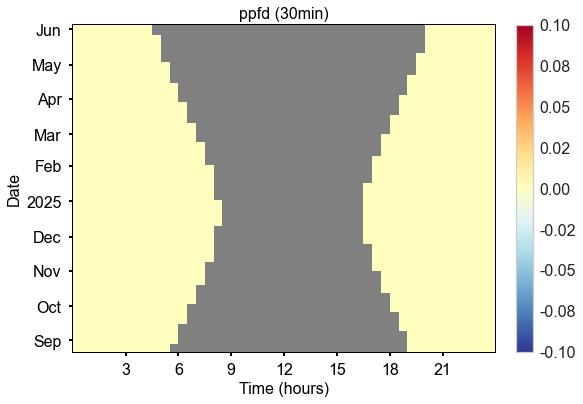

In [33]:
HeatmapDateTime(_df.loc[nighttime_ix, var]).plot()

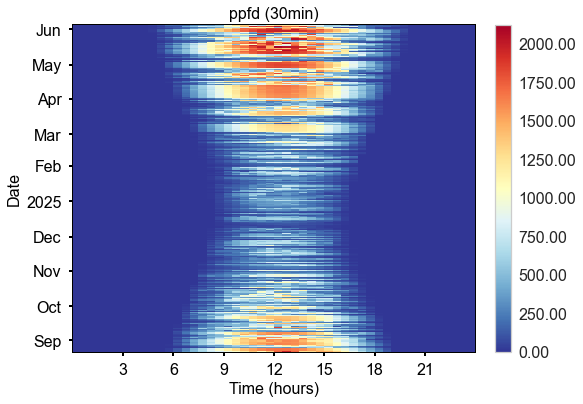

In [34]:
HeatmapDateTime(_df[var]).plot()

### Fill

In [35]:
# Gap-filling with XGBoost only if the variable has missing records
n_gaps = _df[var].isnull().sum()
if n_gaps > 0:
    print(f'{var}: {n_gaps} missing records, gap-filling with XGBoost')
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_
else:
    print(f'{var}: no missing records, gap-filling not needed')

ppfd: no missing records, gap-filling not needed


### Add to data

In [36]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [37]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

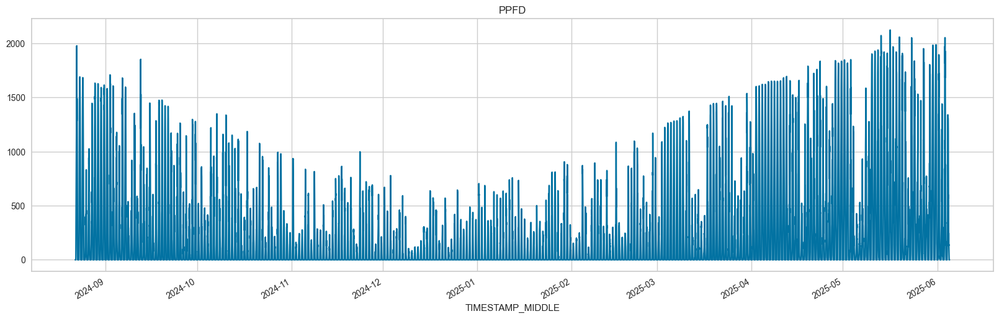

In [38]:
title = "PPFD"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

## Calculate VPD (kPa)

In [39]:
from diive.pkgs.createvar.vpd import calc_vpd_from_ta_rh

In [40]:
var = 'vpd'

In [41]:
vpd = calc_vpd_from_ta_rh(df=meteo, rh_col='rh', ta_col='ta')
vpd

TIMESTAMP_MIDDLE
2024-08-22 00:15:00    0.141369
2024-08-22 00:45:00    0.130055
2024-08-22 01:15:00    0.118427
2024-08-22 01:45:00    0.103376
2024-08-22 02:15:00    0.113850
                         ...   
2025-06-04 21:45:00    0.308913
2025-06-04 22:15:00    0.275008
2025-06-04 22:45:00    0.288298
2025-06-04 23:15:00    0.276955
2025-06-04 23:45:00    0.239388
Freq: 30min, Name: VPD, Length: 13776, dtype: float64

In [42]:
meteo[var] = vpd

In [43]:
_df = pd.DataFrame()
_df[var] = meteo[var].copy()
_df['sw_in'] = meteo['sw_in'].copy()
_df['ta'] = meteo['ta'].copy()
_df

,vpd,sw_in,ta
TIMESTAMP_MIDDLE,,,
2024-08-22 00:15:00,0.141369,0.0,11.276667
2024-08-22 00:45:00,0.130055,0.0,11.043333
2024-08-22 01:15:00,0.118427,0.0,10.890000
2024-08-22 01:45:00,0.103376,0.0,10.720000
2024-08-22 02:15:00,0.113850,0.0,10.820000
...,...,...,...
2025-06-04 21:45:00,0.308913,0.0,15.693333
2025-06-04 22:15:00,0.275008,0.0,15.516667
2025-06-04 22:45:00,0.288298,0.0,15.660000


### Fill

In [44]:
# Gap-filling with XGBoost only if the variable has missing records
n_gaps = _df[var].isnull().sum()
if n_gaps > 0:
    print(f'{var}: {n_gaps} missing records, gap-filling with XGBoost')
    xgb = XGBoostTS(
        input_df=_df,
        target_col=var,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=1000,
        random_state=42,
        early_stopping_rounds=50,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_
else:
    print(f'{var}: no missing records, gap-filling not needed')

vpd: no missing records, gap-filling not needed


### Add to data

In [45]:
# Combine data
if _df[var].isnull().any():
    meteo[var] = results[f'{var}_gfXG'].copy()
    meteo[var]
else:
    meteo[var] = _df[var].copy()
    meteo[var]

In [46]:
# Combine flags
if _df[var].isnull().any():
    meteo[f'FLAG_{var}_ISFILLED'] = results[f'FLAG_{var}_gfXG_ISFILLED'].copy()
    meteo[f'FLAG_{var}_ISFILLED']

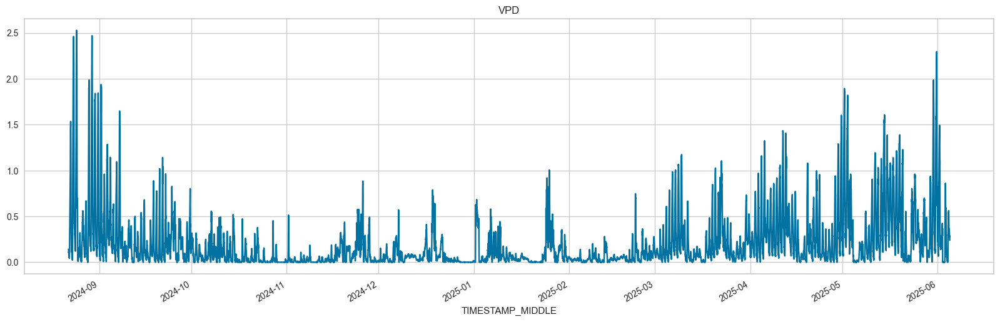

In [47]:
title = "VPD"
# meteo[['SW_IN', 'FLAG_SW_IN_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));

if _df[var].isnull().any():
    meteo[[var, f'FLAG_{var}_ISFILLED']].plot(x_compat=True, title=title, subplots=True, figsize=(20, 6));
else:
    meteo[var].plot(x_compat=True, title=title, figsize=(20, 6))

</br>

## TS

### TS_0.05

ts_0.05: no missing records, gap-filling not needed


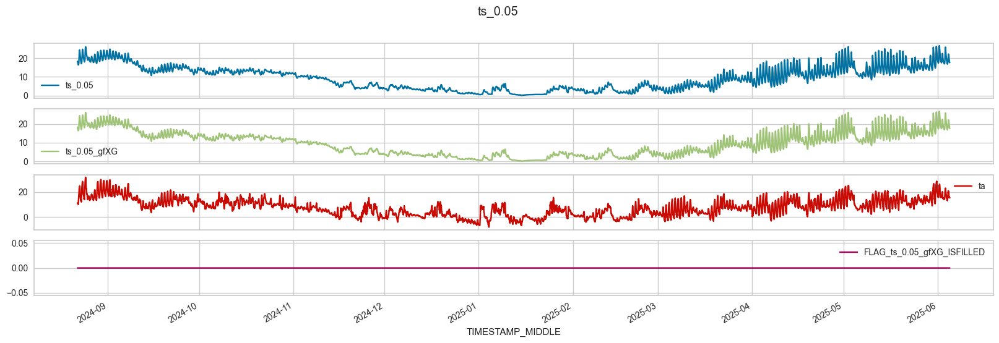

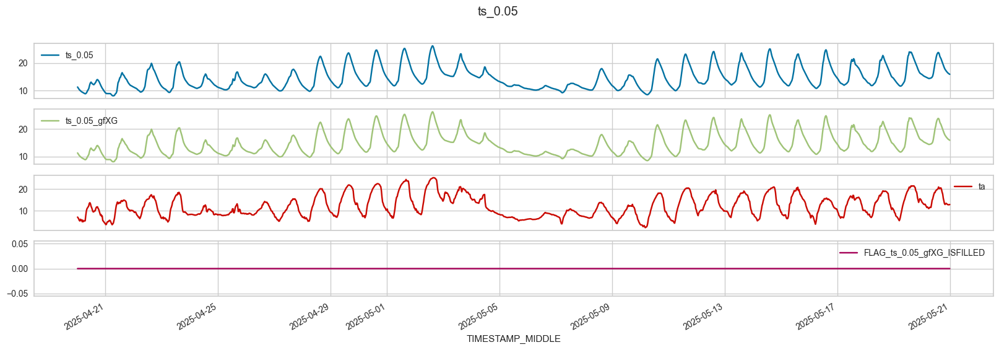

In [48]:
TARGET_COL = 'ts_0.05'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Gap-filling with XGBoost only if the variable has missing records
n_gaps = meteo[TARGET_COL].isnull().sum()
if n_gaps > 0:
    print(f'{TARGET_COL}: {n_gaps} missing records, gap-filling with XGBoost')
    # Dataframe for gap-filling
    _df = pd.DataFrame()
    _df[TARGET_COL] = meteo[TARGET_COL].copy()
    _df['ta'] = meteo['ta']
    _df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()

    # XGBoost
    xgb = XGBoostTS(
        input_df=_df,
        target_col=TARGET_COL,
        features_lag=[-10, -1],
        features_lag_exclude_cols=None,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=500,
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_

    # Add results to main data
    meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
    meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]
else:
    # no gaps: the gap-filled variable equals the measured one, flag 0 = measured
    print(f'{TARGET_COL}: no missing records, gap-filling not needed')
    meteo[TARGET_GAPFILLED_COL] = meteo[TARGET_COL].copy()
    meteo[FLAG_GAPFILLED_COL] = 0

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, 'ta', FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2025-04-20':'2025-05-20'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### TS_0.15

ts_0.15: no missing records, gap-filling not needed


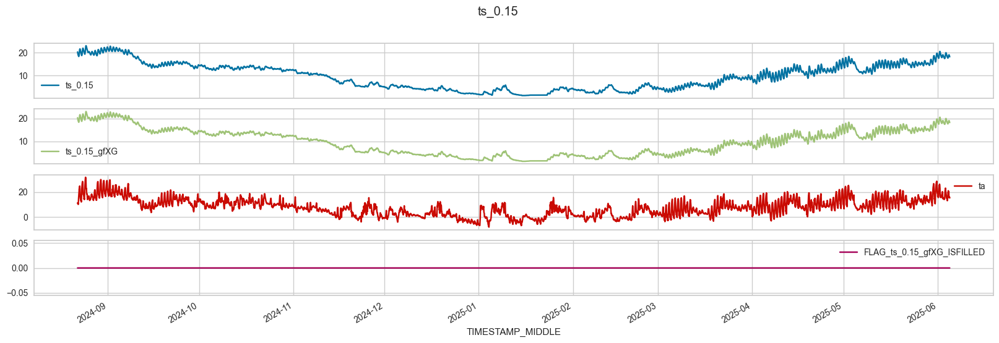

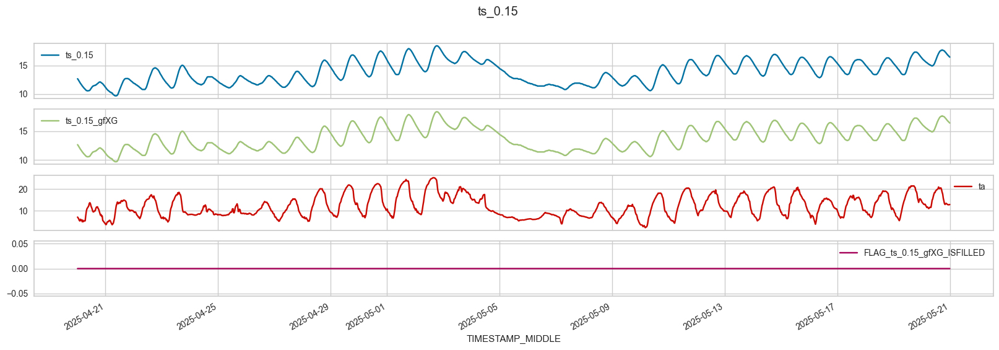

In [49]:
TARGET_COL = 'ts_0.15'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Gap-filling with XGBoost only if the variable has missing records
n_gaps = meteo[TARGET_COL].isnull().sum()
if n_gaps > 0:
    print(f'{TARGET_COL}: {n_gaps} missing records, gap-filling with XGBoost')
    # Dataframe for gap-filling
    _df = pd.DataFrame()
    _df[TARGET_COL] = meteo[TARGET_COL].copy()
    _df['ta'] = meteo['ta']
    _df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
    _df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

    # XGBoost
    xgb = XGBoostTS(
        input_df=_df,
        target_col=TARGET_COL,
        features_lag=[-10, -1],
        features_lag_exclude_cols=None,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=500,
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_

    # Add results to main data
    meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
    meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]
else:
    # no gaps: the gap-filled variable equals the measured one, flag 0 = measured
    print(f'{TARGET_COL}: no missing records, gap-filling not needed')
    meteo[TARGET_GAPFILLED_COL] = meteo[TARGET_COL].copy()
    meteo[FLAG_GAPFILLED_COL] = 0

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, 'ta', FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2025-04-20':'2025-05-20'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### TS_3

ts_0.3: no missing records, gap-filling not needed


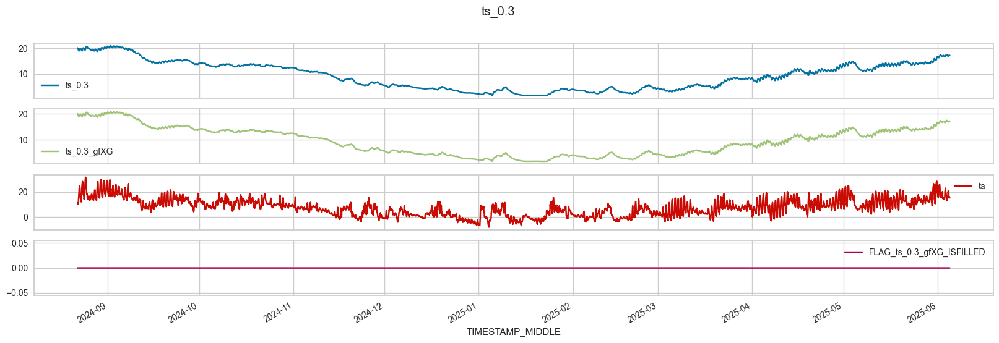

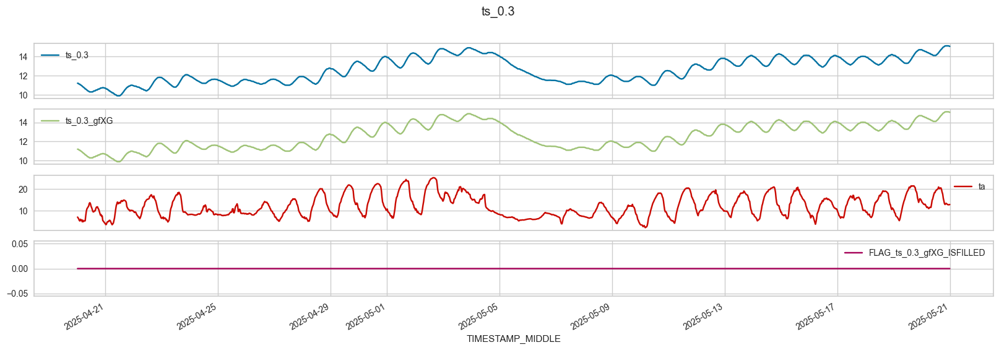

In [50]:
TARGET_COL = 'ts_0.3'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Gap-filling with XGBoost only if the variable has missing records
n_gaps = meteo[TARGET_COL].isnull().sum()
if n_gaps > 0:
    print(f'{TARGET_COL}: {n_gaps} missing records, gap-filling with XGBoost')
    # Dataframe for gap-filling
    _df = pd.DataFrame()
    _df[TARGET_COL] = meteo[TARGET_COL].copy()
    _df['ta'] = meteo['ta']
    _df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
    _df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()
    _df['ta_roll_12h'] = meteo['ta'].rolling(window=24, min_periods=1).mean()

    # XGBoost
    xgb = XGBoostTS(
        input_df=_df,
        target_col=TARGET_COL,
        features_lag=[-20, -1],
        features_lag_exclude_cols=None,
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=500,
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_

    # Add results to main data
    meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
    meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]
else:
    # no gaps: the gap-filled variable equals the measured one, flag 0 = measured
    print(f'{TARGET_COL}: no missing records, gap-filling not needed')
    meteo[TARGET_GAPFILLED_COL] = meteo[TARGET_COL].copy()
    meteo[FLAG_GAPFILLED_COL] = 0

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, 'ta', FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2025-04-20':'2025-05-20'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

## SWC 5 TM

### SWC_0.05

swc_0.05: no missing records, gap-filling not needed


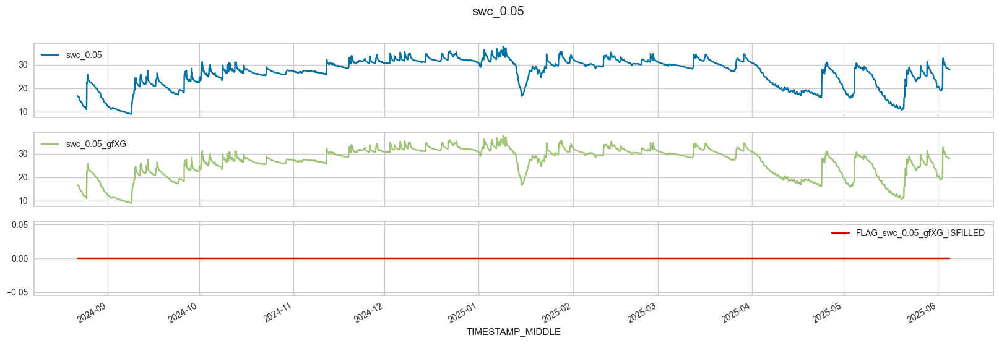

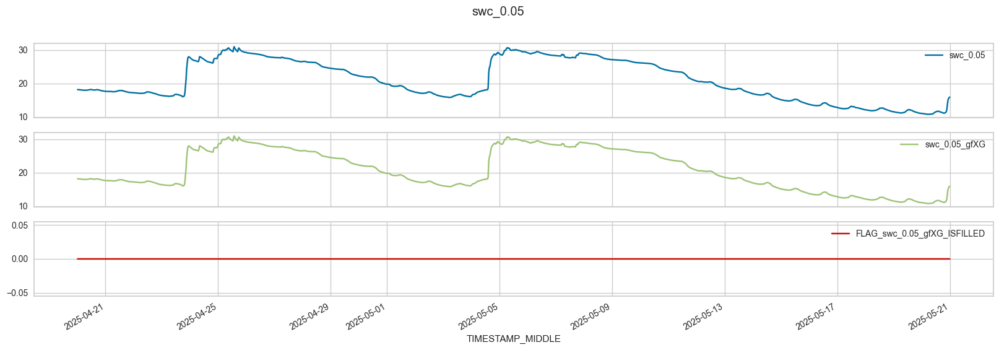

In [51]:
TARGET_COL = 'swc_0.05'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Gap-filling with XGBoost only if the variable has missing records
n_gaps = meteo[TARGET_COL].isnull().sum()
if n_gaps > 0:
    print(f'{TARGET_COL}: {n_gaps} missing records, gap-filling with XGBoost')
    # Dataframe for gap-filling
    _df = pd.DataFrame()
    _df[TARGET_COL] = meteo[TARGET_COL].copy()
    _df['prec'] = meteo['prec'].copy()
    _df['timesince_prec'] = meteo['timesince_prec'].copy()
    _df['prec_roll_24h'] = meteo['prec'].rolling(window=48, min_periods=1).sum()
    _df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
    _df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

    # XGBoost
    xgb = XGBoostTS(
        input_df=_df,
        target_col=TARGET_COL,
        features_lag=[-10, -1],
        features_lag_exclude_cols=['timesince_prec'],
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=500,
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )
    xgb.reduce_features()
    xgb.report_feature_reduction()
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_

    # Add results to main data
    meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
    meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]
else:
    # no gaps: the gap-filled variable equals the measured one, flag 0 = measured
    print(f'{TARGET_COL}: no missing records, gap-filling not needed')
    meteo[TARGET_GAPFILLED_COL] = meteo[TARGET_COL].copy()
    meteo[FLAG_GAPFILLED_COL] = 0

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2025-04-20':'2025-05-20'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### SWC_0.15

swc_0.15: no missing records, gap-filling not needed


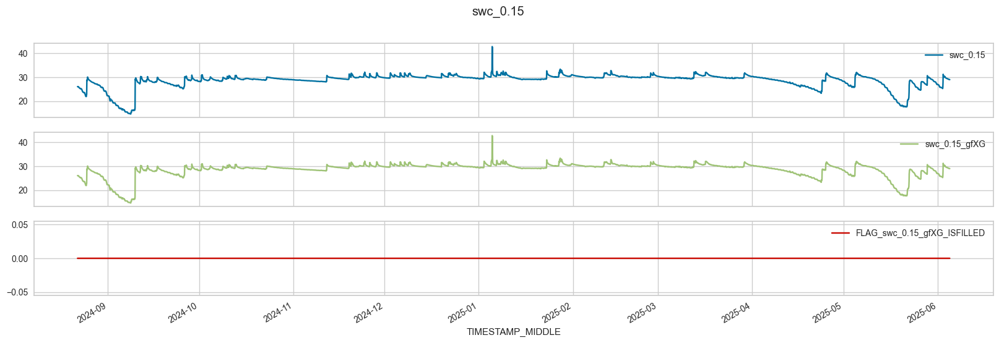

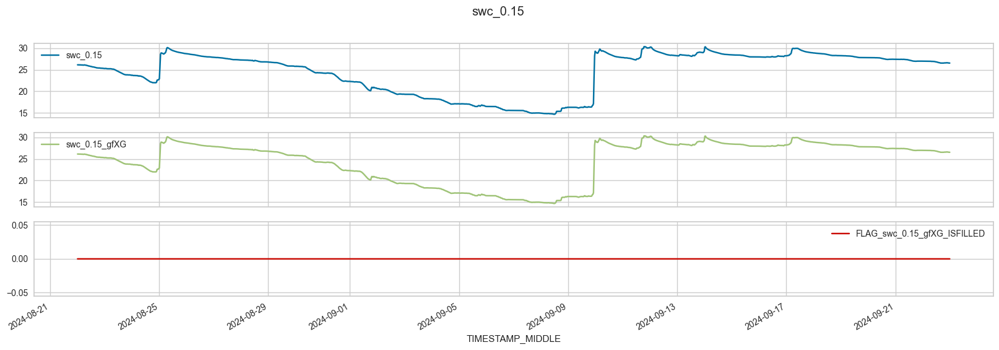

In [52]:
TARGET_COL = 'swc_0.15'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Gap-filling with XGBoost only if the variable has missing records
n_gaps = meteo[TARGET_COL].isnull().sum()
if n_gaps > 0:
    print(f'{TARGET_COL}: {n_gaps} missing records, gap-filling with XGBoost')
    # Dataframe for gap-filling
    _df = pd.DataFrame()
    _df[TARGET_COL] = meteo[TARGET_COL].copy()
    _df['prec'] = meteo['prec'].copy()
    _df['timesince_prec'] = meteo['timesince_prec'].copy()
    _df['prec_roll_24h'] = meteo['prec'].rolling(window=48, min_periods=1).sum()
    _df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
    _df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

    # XGBoost
    xgb = XGBoostTS(
        input_df=_df,
        target_col=TARGET_COL,
        features_lag=[-10, -1],
        features_lag_exclude_cols=['timesince_prec'],
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=500,
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )
    xgb.reduce_features()
    xgb.report_feature_reduction()
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_

    # Add results to main data
    meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
    meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]
else:
    # no gaps: the gap-filled variable equals the measured one, flag 0 = measured
    print(f'{TARGET_COL}: no missing records, gap-filling not needed')
    meteo[TARGET_GAPFILLED_COL] = meteo[TARGET_COL].copy()
    meteo[FLAG_GAPFILLED_COL] = 0

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-08-22':'2024-09-22'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

### SWC_0.3

swc_0.3: no missing records, gap-filling not needed


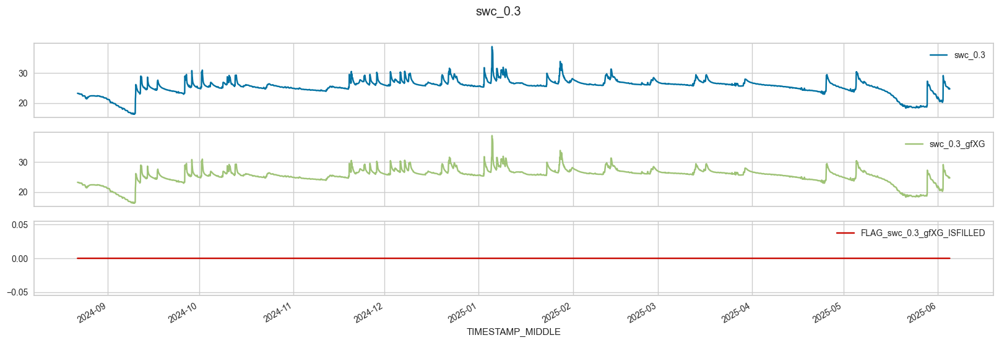

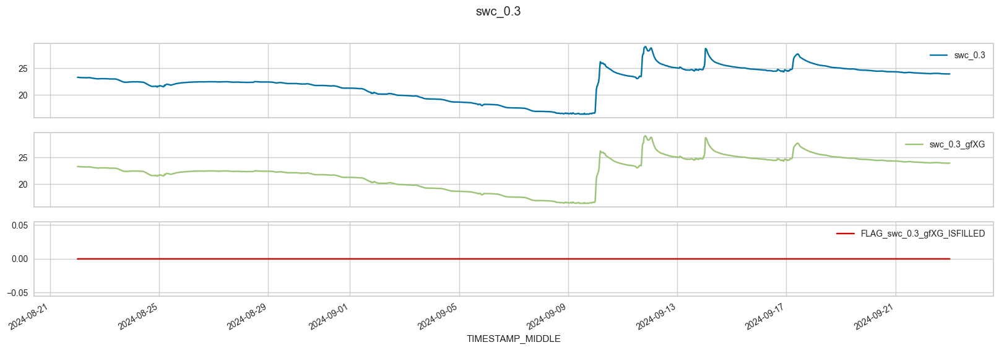

In [53]:
TARGET_COL = 'swc_0.3'
TARGET_GAPFILLED_COL = f'{TARGET_COL}_gfXG'
FLAG_GAPFILLED_COL = f'FLAG_{TARGET_GAPFILLED_COL}_ISFILLED'

# Gap-filling with XGBoost only if the variable has missing records
n_gaps = meteo[TARGET_COL].isnull().sum()
if n_gaps > 0:
    print(f'{TARGET_COL}: {n_gaps} missing records, gap-filling with XGBoost')
    # Dataframe for gap-filling
    _df = pd.DataFrame()
    _df[TARGET_COL] = meteo[TARGET_COL].copy()
    _df['prec'] = meteo['prec'].copy()
    _df['timesince_prec'] = meteo['timesince_prec'].copy()
    _df['prec_roll_24h'] = meteo['prec'].rolling(window=48, min_periods=1).sum()
    _df['ta_roll_3h'] = meteo['ta'].rolling(window=6, min_periods=1).mean()
    _df['ta_roll_6h'] = meteo['ta'].rolling(window=12, min_periods=1).mean()

    # XGBoost
    xgb = XGBoostTS(
        input_df=_df,
        target_col=TARGET_COL,
        features_lag=[-10, -1],
        features_lag_exclude_cols=['timesince_prec'],
        perm_n_repeats=10,
        include_timestamp_as_features=True,
        add_continuous_record_number=True,
        n_estimators=500,
        random_state=42,
        early_stopping_rounds=10,
        n_jobs=-1
    )
    xgb.reduce_features()
    xgb.report_feature_reduction()
    xgb.trainmodel(showplot_scores=False, showplot_importance=False)
    xgb.report_traintest()
    xgb.fillgaps(showplot_scores=False, showplot_importance=False)
    xgb.report_gapfilling()
    results = xgb.gapfilling_df_

    # Add results to main data
    meteo[TARGET_GAPFILLED_COL] = results[TARGET_GAPFILLED_COL]
    meteo[FLAG_GAPFILLED_COL] = results[FLAG_GAPFILLED_COL]
else:
    # no gaps: the gap-filled variable equals the measured one, flag 0 = measured
    print(f'{TARGET_COL}: no missing records, gap-filling not needed')
    meteo[TARGET_GAPFILLED_COL] = meteo[TARGET_COL].copy()
    meteo[FLAG_GAPFILLED_COL] = 0

# Plot
plotdf = meteo[[TARGET_COL, TARGET_GAPFILLED_COL, FLAG_GAPFILLED_COL]].copy()
plotdf.plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));
plotdf['2024-08-22':'2024-09-22'].plot(x_compat=True, title=TARGET_COL, subplots=True, figsize=(20, 6));

# **Plots**

In [54]:
_plot_df = meteo.copy()
_plot_df = _plot_df.replace(-9999, np.nan)

## Time series plot

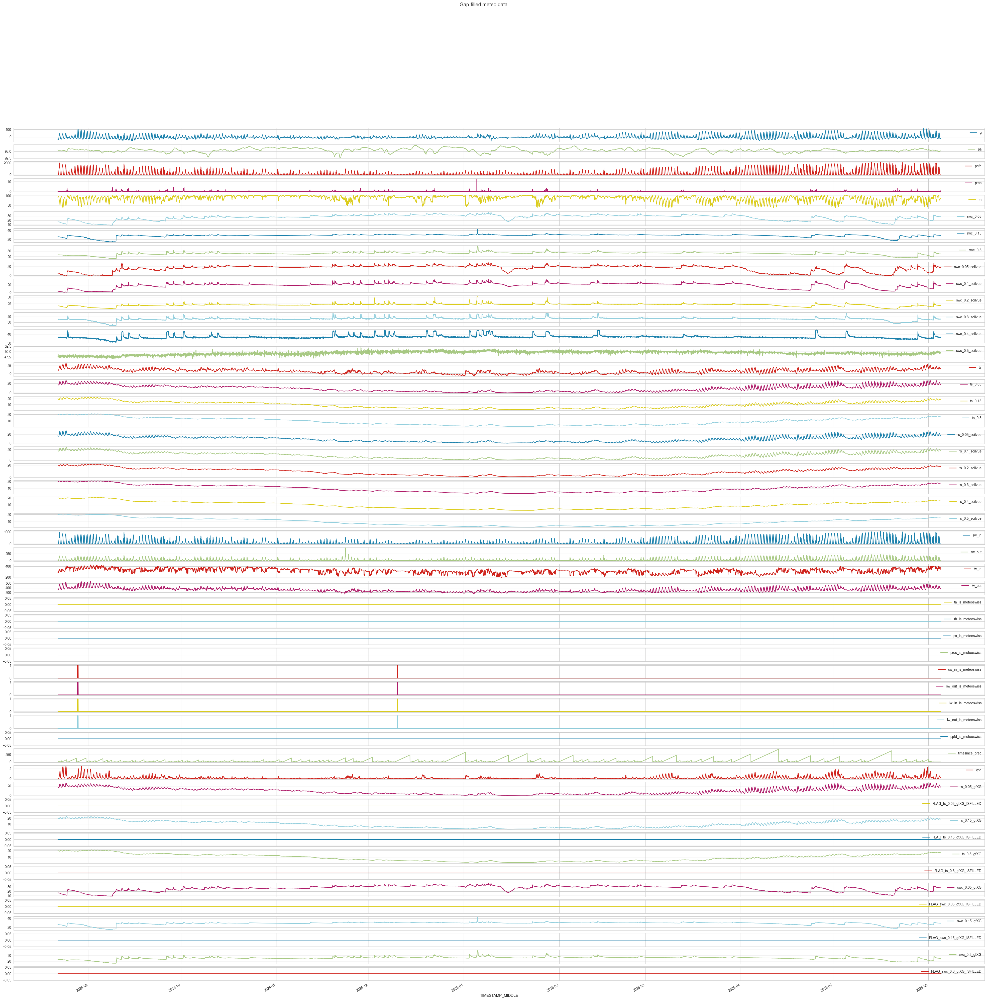

In [55]:
_plot_df.plot(subplots=True, figsize=(50, 50), title="Gap-filled meteo data", alpha=.9, x_compat=True);

## Heatmaps

C:\Users\turcof\.conda\envs\tan\Lib\site-packages\diive\core\plotting\heatmap_base.py:101: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, self.ax = plt.subplots(constrained_layout=True, figsize=self.figsize, dpi=self.figdpi)


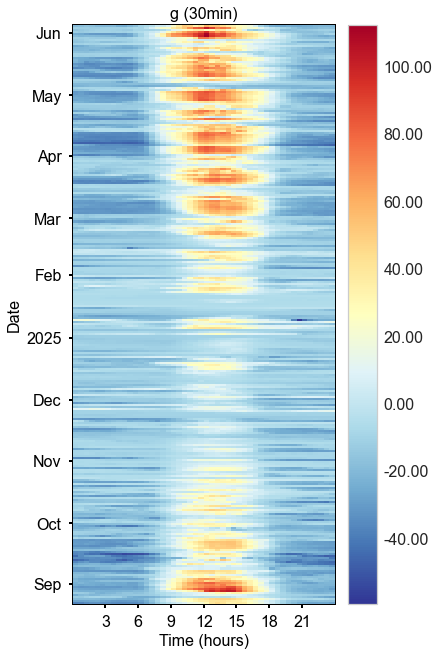

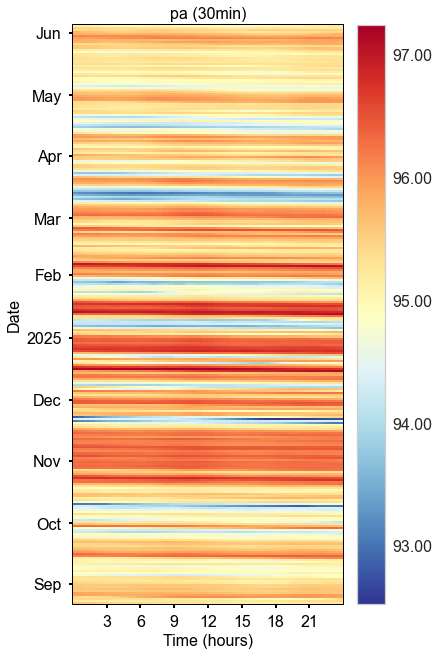

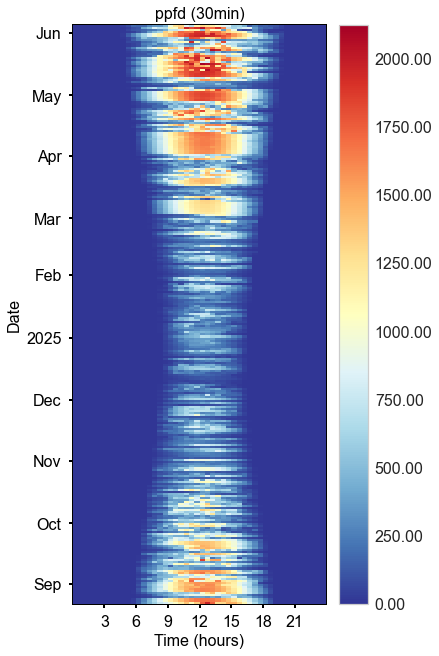

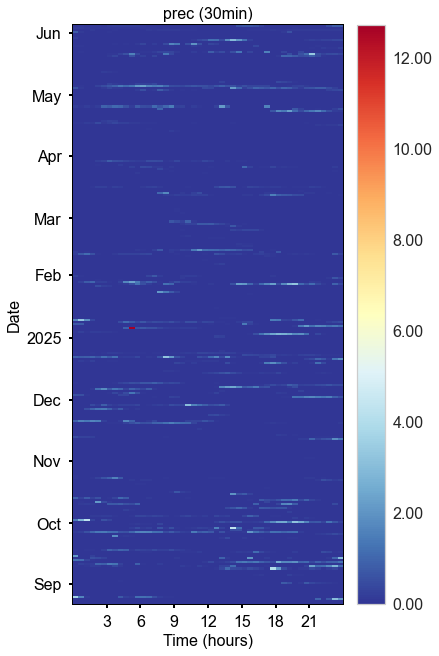

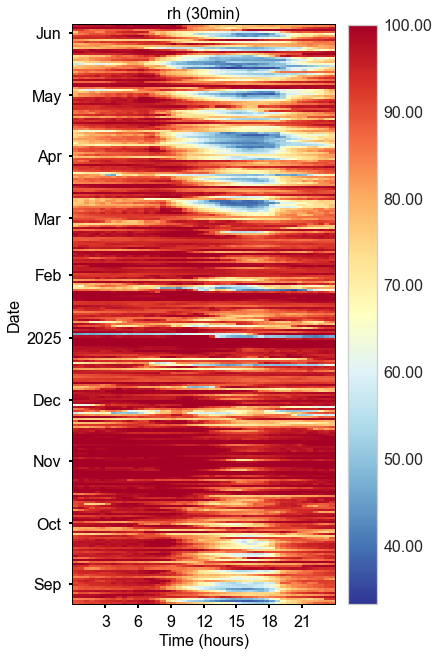

...

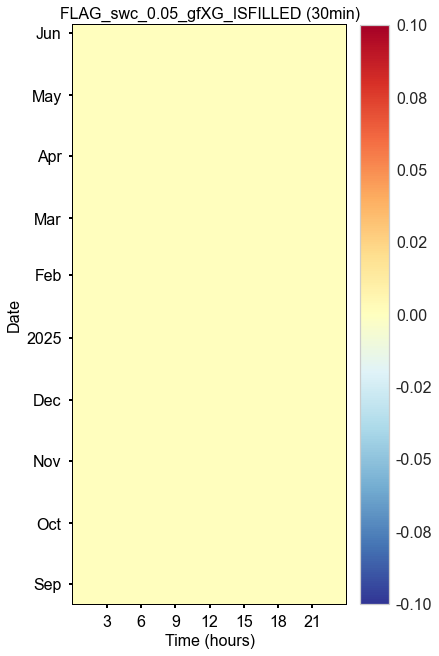

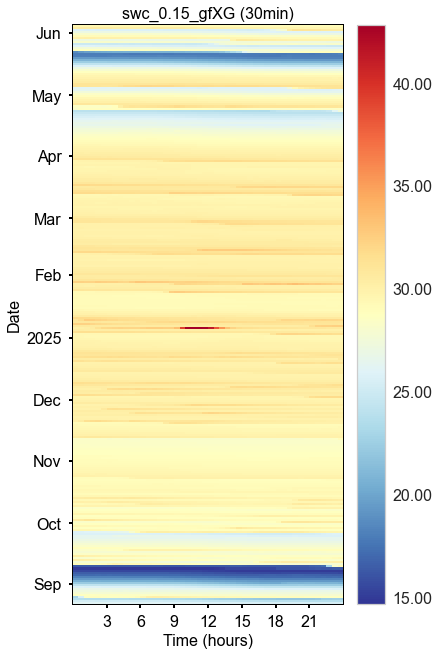

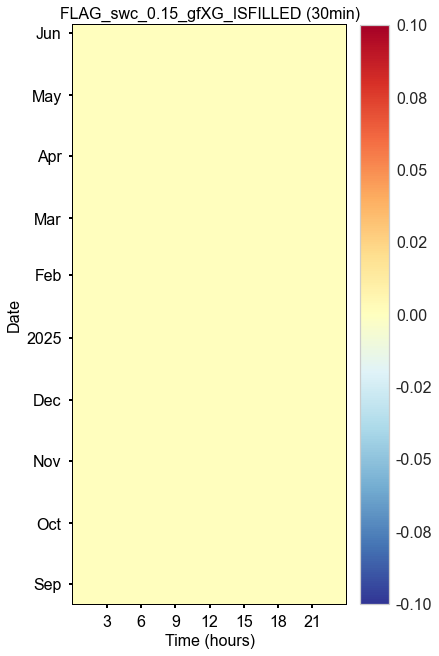

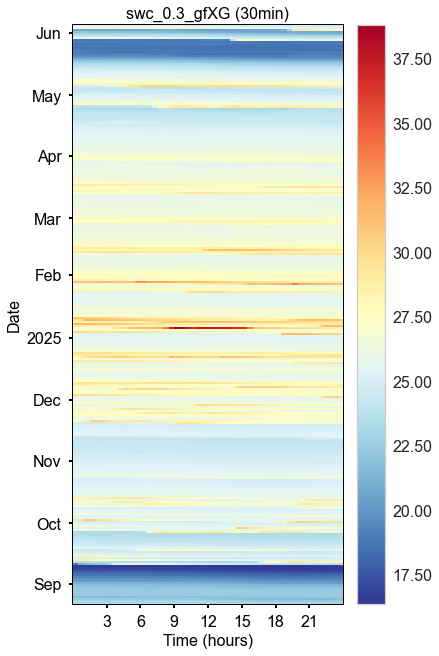

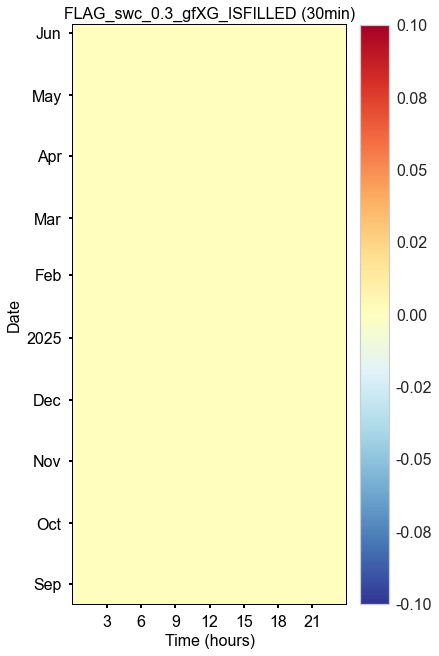

In [56]:
for col in _plot_df.columns:
    series = _plot_df[col]
    series.name = col
    HeatmapDateTime(series, figsize=(6, 9)).show()

</br>

# **Stats**

In [57]:
meteo.describe().T

,count,mean,std,min,25%,50%,75%,max
g,13776.0,-2.840606,22.332583,-59.435390,-15.923946,-7.832755,4.451478,112.437767
pa,13776.0,95.419212,0.740902,92.529667,94.992667,95.457667,95.946083,97.246333
ppfd,13776.0,230.435063,409.575163,0.000000,0.000000,0.000000,284.850824,2124.180139
prec,13776.0,0.054009,0.266020,0.000000,0.000000,0.000000,0.000000,12.716000
rh,13776.0,86.861174,13.851171,33.253333,80.843333,91.683333,97.319999,100.000000
...,...,...,...,...,...,...,...,...
FLAG_swc_0.05_gfXG_ISFILLED,13776.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
swc_0.15_gfXG,13776.0,28.731671,2.954702,14.694945,28.460547,29.633035,30.199810,42.839407
FLAG_swc_0.15_gfXG_ISFILLED,13776.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
swc_0.3_gfXG,13776.0,25.503888,2.482881,16.373105,24.801469,25.932308,26.695586,38.817639


</br>

In [58]:
meteo

,g,pa,ppfd,prec,rh,swc_0.05,...,swc_0.05_gfXG,FLAG_swc_0.05_gfXG_ISFILLED,swc_0.15_gfXG,FLAG_swc_0.15_gfXG_ISFILLED,swc_0.3_gfXG,FLAG_swc_0.3_gfXG_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2024-08-22 00:15:00,-37.436829,95.590000,0.0,0.000,89.440002,16.752412,...,16.752412,0,26.141747,0,23.278843,0
2024-08-22 00:45:00,-36.883657,95.579000,0.0,0.000,90.133334,16.707313,...,16.707313,0,26.144934,0,23.268508,0
2024-08-22 01:15:00,-34.570664,95.556333,0.0,0.000,90.923334,16.672328,...,16.672328,0,26.134158,0,23.272999,0
2024-08-22 01:45:00,-33.094323,95.527000,0.0,0.000,91.986667,16.611719,...,16.611719,0,26.123198,0,23.264485,0
2024-08-22 02:15:00,-32.885476,95.500000,0.0,0.000,91.233334,16.552405,...,16.552405,0,26.132820,0,23.234120,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:45:00,-23.907052,95.134000,0.0,0.017,82.700000,27.981393,...,27.981393,0,29.086370,0,24.709643,0
2025-06-04 22:15:00,-22.316862,95.139333,0.0,0.034,84.423333,27.982679,...,27.982679,0,29.086370,0,24.707201,0
2025-06-04 22:45:00,-21.379620,95.165333,0.0,0.425,83.819999,27.975655,...,27.975655,0,29.082396,0,24.680151,0


</br>

# **Save measured and gap-filled data to parquet**

In [59]:
OUTNAME = "13.1_CH-TAN_meteo_gapfilled"
OUTPATH = ""
filepath = save_parquet(filename=OUTNAME, data=meteo, outpath=OUTPATH)

Saved file 13.1_CH-TAN_meteo_gapfilled.parquet (0.112 seconds).


</br>

# **End of notebook**.

In [60]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-10-06 15:21:14
